Instalamos todo

In [4]:
!pip uninstall pgmpy
!pip install pgmpy==0.1.18
!pip install pandas numpy kaggle
!pip install bnlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 773.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

Se importan las librerias que serán usadas

In [13]:
import pandas as pd
import bnlearn as bn
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


Se añade la llave para poder hacer uso de Kaggle


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alejandroignac","key":"2568dc3aad024639d6e79cfd24dc2657"}'}

Se crea un directorio donde estará la llave

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/


Se asignan permiso


In [4]:
!chmod 600 /root/.kaggle/kaggle.json



Descarga del dataset

In [5]:
!kaggle datasets download -d miadul/brain-tumor-dataset



Dataset URL: https://www.kaggle.com/datasets/miadul/brain-tumor-dataset
License(s): MIT


Descomprensión del dataset

In [6]:
!unzip brain-tumor-dataset.zip


Archive:  brain-tumor-dataset.zip
  inflating: brain_tumor_dataset.csv  


Se verifica que esté en el directorio

In [7]:
!ls


brain_tumor_dataset.csv  brain-tumor-dataset.zip  sample_data


Confirmamación viendo las primeras filas

In [8]:
import pandas as pd
df = pd.read_csv('brain_tumor_dataset.csv')
df.head()


,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


Uso del algoritmo hill climbing, se modifican los valores de las columnas para crear un metodo de aprendizaje


[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
AprendIzaje del modelo: [('Tumor_Type', 'Survival_Class'), ('Tumor_Type', 'Stage'), ('Stage', 'Chemotherapy'), ('Chemotherapy', 'Survival_Class'), ('MRI_Result', 'Tumor_Type')]
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


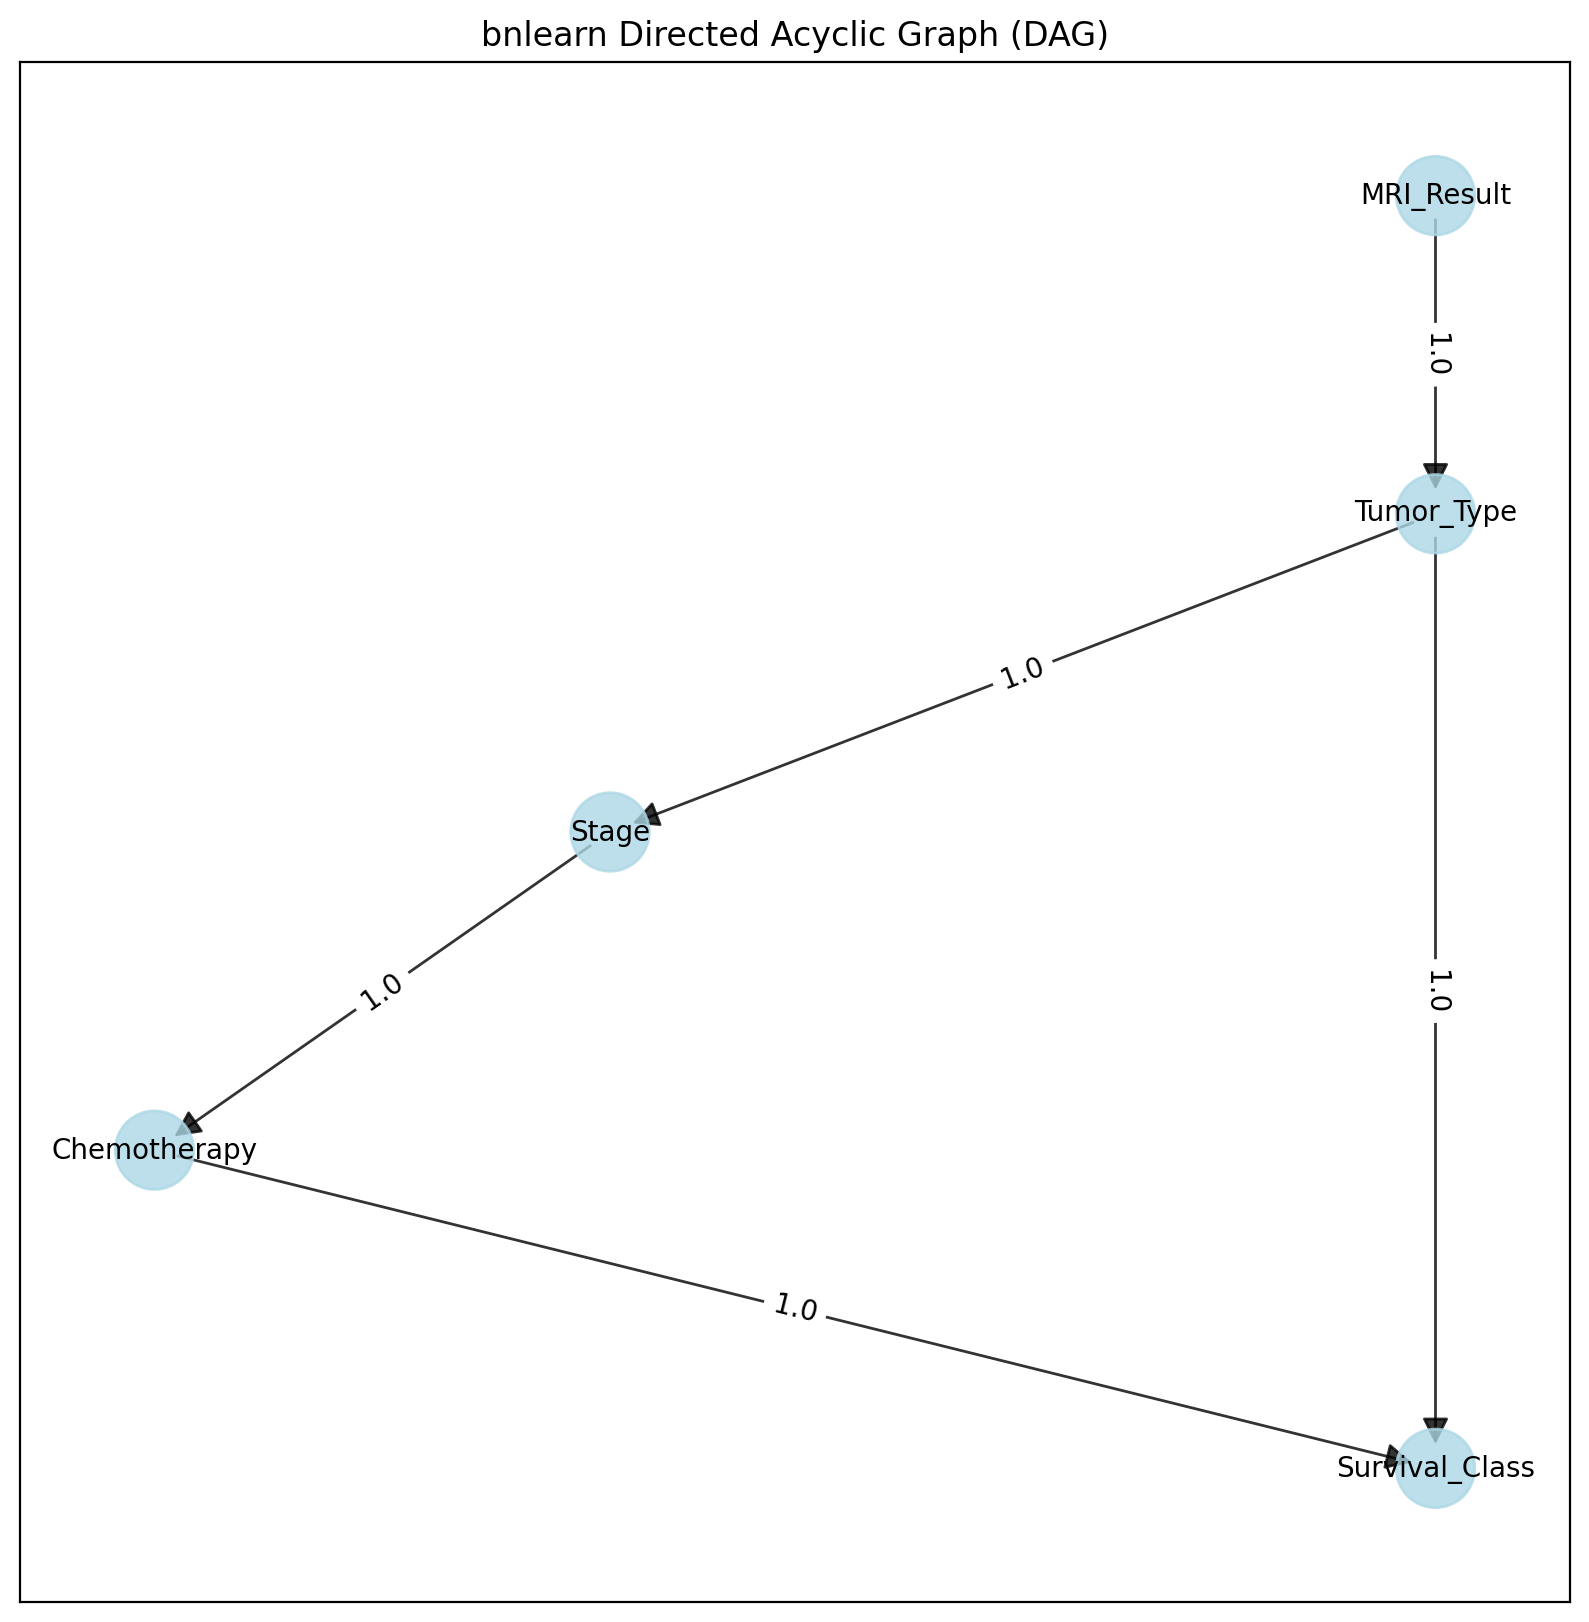

In [34]:
np.random.seed(42)
n = 1000

df_sim = pd.DataFrame({
    'Tumor_Type': np.random.choice(['Benign', 'Malignant'], size=n, p=[0.4, 0.6]),
})

df_sim['Stage'] = df_sim['Tumor_Type'].apply(
    lambda x: np.random.choice(['I', 'II', 'III', 'IV'],
        p=[0.5, 0.3, 0.15, 0.05]) if x == 'Benign' else
        np.random.choice(['I', 'II', 'III', 'IV'], p=[0.1, 0.2, 0.4, 0.3])
)

df_sim['Chemotherapy'] = df_sim['Stage'].apply(
    lambda x: 'Yes' if x in ['III', 'IV'] else 'No'
)

df_sim['MRI_Result'] = df_sim['Tumor_Type'].apply(
    lambda x: np.random.choice(['Positive', 'Negative'], p=[0.9, 0.1]) if x == 'Malignant'
    else np.random.choice(['Positive', 'Negative'], p=[0.3, 0.7])
)

def survival_class(row):
    if row['Tumor_Type'] == 'Benign':
        return np.random.choice(['Alta', 'Media'], p=[0.8, 0.2])
    else:
        if row['Chemotherapy'] == 'Yes':
            return np.random.choice(['Alta', 'Media', 'Baja'], p=[0.2, 0.5, 0.3])
        else:
            return np.random.choice(['Alta', 'Media', 'Baja'], p=[0.1, 0.3, 0.6])

df_sim['Survival_Class'] = df_sim.apply(survival_class, axis=1)

for col in df_sim.columns:
    df_sim[col] = df_sim[col].astype('category')

model_hc = bn.structure_learning.fit(df_sim, methodtype='hc', scoretype='bic')
print("AprendIzaje del modelo:", model_hc['model_edges'])

bn.plot(model_hc)

from pgmpy.models import BayesianNetwork as PGMPYBayesNet
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

pgm_model = PGMPYBayesNet(model_hc['model_edges'])

pgm_model.fit(df_sim, estimator=MaximumLikelihoodEstimator)


Inferencias para ver el aprendizaje

In [33]:

query1 = inference.query(variables=['Tumor_Type'], evidence={'MRI_Result': 'Positive'})
print("\n P(Tumor_Type | MRI_Result = 'Positive'):")
print(query1)

query2 = inference.query(variables=['Stage'], evidence={'Tumor_Type': 'Benign'})
print("\n P(Stage | Tumor_Type = 'Benign'):")
print(query2)

query3 = inference.query(
    variables=['Survival_Class'],
    evidence={'Tumor_Type': 'Malignant', 'Stage': 'IV', 'Chemotherapy': 'Yes'}
)
print("\n P(Survival_Class | Tumor_Type = 'Malignant', Stage = 'IV', Chemotherapy = 'Yes'):")
print(query3)

query4 = inference.query(variables=['Chemotherapy'], evidence={'Tumor_Type': 'Malignant'})
print("\n P(Chemotherapy | Tumor_Type = 'Malignant'):")
print(query4)



  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


 P(Tumor_Type | MRI_Result = 'Positive'):
+-----------------------+-------------------+
| Tumor_Type            |   phi(Tumor_Type) |
+=======================+===================+
| Tumor_Type(Benign)    |            0.1981 |
+-----------------------+-------------------+
| Tumor_Type(Malignant) |            0.8019 |
+-----------------------+-------------------+


0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]


 P(Survival_Class | Tumor_Type = 'Malignant', Stage = 'IV', Chemotherapy = 'Yes'):
+-----------------------+-----------------------+
| Survival_Class        |   phi(Survival_Class) |
+=======================+=======================+
| Survival_Class(Alta)  |                0.2443 |
+-----------------------+-----------------------+
| Survival_Class(Baja)  |                0.2614 |
+-----------------------+-----------------------+
| Survival_Class(Media) |                0.4943 |
+-----------------------+-----------------------+


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


 P(Chemotherapy | Tumor_Type = 'Malignant'):
+-------------------+---------------------+
| Chemotherapy      |   phi(Chemotherapy) |
+===================+=====================+
| Chemotherapy(No)  |              0.2971 |
+-------------------+---------------------+
| Chemotherapy(Yes) |              0.7029 |
+-------------------+---------------------+


Modelo de aprendizaje de constraint based

[bnlearn] >Computing best DAG using [cs]
[bnlearn] >Build skeleton with [chi_square] and alpha=0.05


  0%|          | 0/5 [00:00<?, ?it/s]

14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=No. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=Yes. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Survival_Class=Baja. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=No. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=Yes. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Survival_Class=Baja. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Chemotherapy | Stage=I. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Chemotherapy | Stage=II. Not enough samples
14-04-25 22:03:44 [root] > INFO     > Skipping the test Tumor_Type ⟂ Chemotherapy | Sta

  0%|          | 0/5 [00:00<?, ?it/s]

14-04-25 22:03:46 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=No. Not enough samples
14-04-25 22:03:46 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=Yes. Not enough samples
14-04-25 22:03:46 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Survival_Class=Baja. Not enough samples
14-04-25 22:03:47 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=No. Not enough samples
14-04-25 22:03:47 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Chemotherapy=Yes. Not enough samples
14-04-25 22:03:47 [root] > INFO     > Skipping the test Tumor_Type ⟂ Stage | Survival_Class=Baja. Not enough samples
14-04-25 22:03:47 [root] > INFO     > Skipping the test Tumor_Type ⟂ Chemotherapy | Stage=I. Not enough samples
14-04-25 22:03:47 [root] > INFO     > Skipping the test Tumor_Type ⟂ Chemotherapy | Stage=II. Not enough samples
14-04-25 22:03:47 [root] > INFO     > Skipping the test Tumor_Type ⟂ Chemotherapy | Sta

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Warning: Structure scoring could not be computed. Method [cs] not supported.
APRENDIZAJE DEL MODELO: [('Chemotherapy', 'Survival_Class'), ('Tumor_Type', 'Survival_Class'), ('Tumor_Type', 'Chemotherapy'), ('Tumor_Type', 'MRI_Result'), ('Stage', 'Survival_Class'), ('Stage', 'Chemotherapy'), ('Stage', 'Tumor_Type')]
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


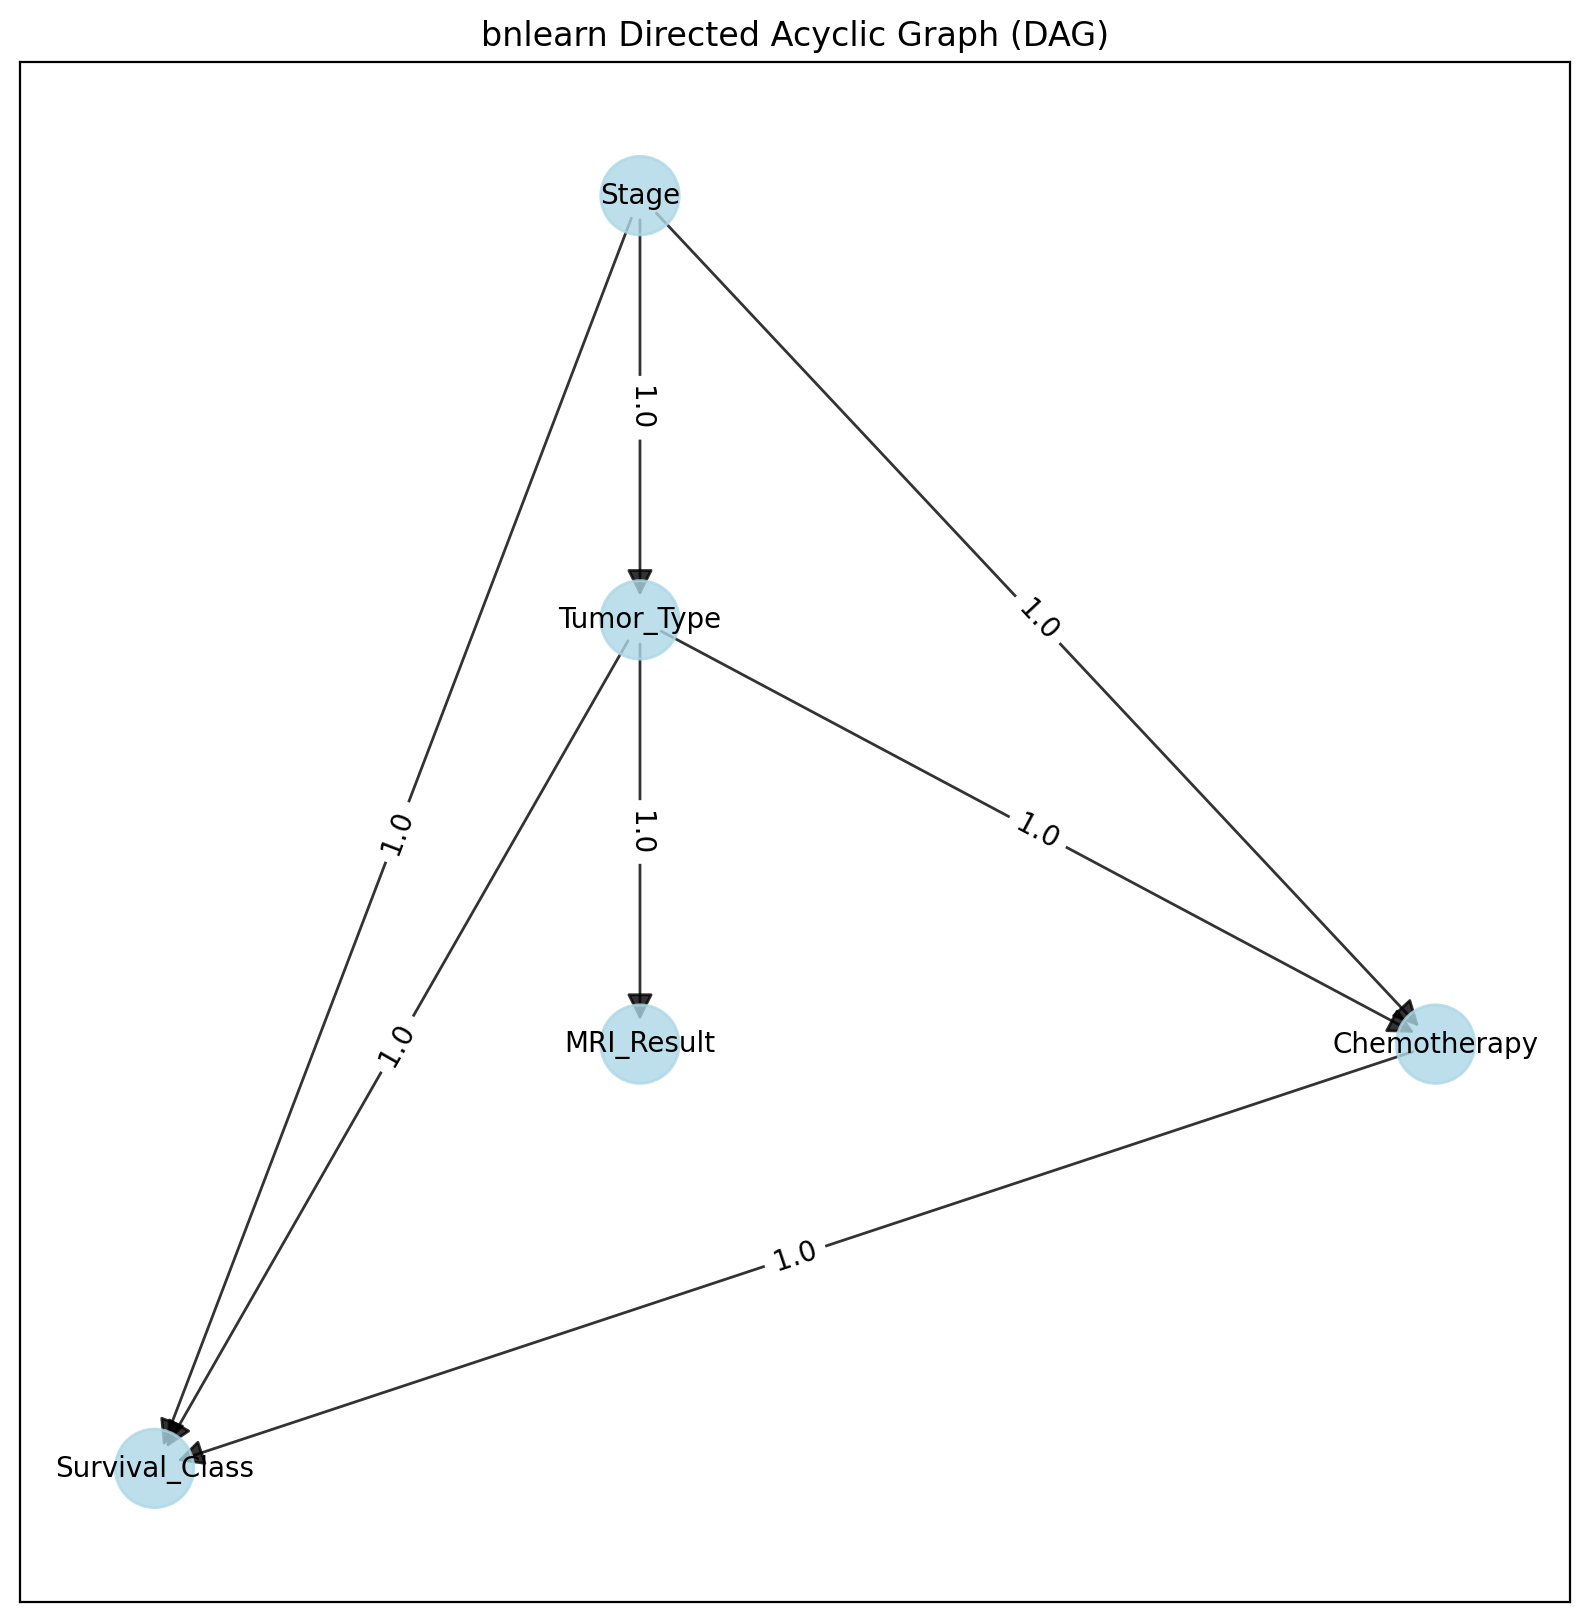

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'Chemotherapy': (282.69, 90.0),
  'Survival_Class': (63.694, 18.0),
  'Tumor_Type': (146.69, 162.0),
  'MRI_Result': (146.69, 90.0),
  'Stage': (146.69, 234.0)},
 'G': <networkx.classes.digraph.DiGraph at 0x7a088a931090>,
 'node_properties': {'Survival_Class': {'node_color': '#ADD8E6',
   'node_size': 800},
  'Chemotherapy': {'node_color': '#ADD8E6', 'node_size': 800},
  'Tumor_Type': {'node_color': '#ADD8E6', 'node_size': 800},
  'Stage': {'node_color': '#ADD8E6', 'node_size': 800},
  'MRI_Result': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('Chemotherapy', 'Survival_Class'): {'color': '#000000',
   'weight': 1.0,
   'pvalue': 1,
   'value': 1.0},
  ('Tumor_Type', 'Survival_Class'): {'color': '#000000',
   'weight': 1.0,
   'pvalue': 1,
   'value': 1.0},
  ('Tumor_Type', 'Chemotherapy'): {'color': '#000000',
   'weight': 1.0,
   'pvalue': 1,
   'value': 1.0},
  ('T

In [32]:

np.random.seed(42)
n = 1000

df_sim = pd.DataFrame({
    'Tumor_Type': np.random.choice(['Benign', 'Malignant'], size=n, p=[0.4, 0.6]),
})

df_sim['Stage'] = df_sim['Tumor_Type'].apply(
    lambda x: np.random.choice(['I', 'II', 'III', 'IV'],
        p=[0.5, 0.3, 0.15, 0.05]) if x == 'Benign' else
        np.random.choice(['I', 'II', 'III', 'IV'], p=[0.1, 0.2, 0.4, 0.3])
)

df_sim['Chemotherapy'] = df_sim['Stage'].apply(
    lambda x: 'Yes' if x in ['III', 'IV'] else 'No'
)

df_sim['MRI_Result'] = df_sim['Tumor_Type'].apply(
    lambda x: np.random.choice(['Positive', 'Negative'], p=[0.9, 0.1]) if x == 'Malignant'
    else np.random.choice(['Positive', 'Negative'], p=[0.3, 0.7])
)

def survival_class(row):
    if row['Tumor_Type'] == 'Benign':
        return np.random.choice(['Alta', 'Media'], p=[0.8, 0.2])
    else:
        if row['Chemotherapy'] == 'Yes':
            return np.random.choice(['Alta', 'Media', 'Baja'], p=[0.2, 0.5, 0.3])
        else:
            return np.random.choice(['Alta', 'Media', 'Baja'], p=[0.1, 0.3, 0.6])

df_sim['Survival_Class'] = df_sim.apply(survival_class, axis=1)

for col in df_sim.columns:
    df_sim[col] = df_sim[col].astype('category')

model_cs = bn.structure_learning.fit(df_sim, methodtype='cs')
print("APRENDIZAJE DEL MODELO:", model_cs['model_edges'])

bn.plot(model_cs)




Inferencias a partir del modelo aprendido anteriormente

In [36]:

query1 = inference.query(variables=['Tumor_Type'], evidence={'MRI_Result': 'Positive'})
print("\n P(Tumor_Type | MRI_Result = 'Positive'):")
print(query1)

query2 = inference.query(variables=['Stage'], evidence={'Tumor_Type': 'Benign'})
print("\n P(Stage | Tumor_Type = 'Benign'):")
print(query2)

query3 = inference.query(
    variables=['Survival_Class'],
    evidence={'Tumor_Type': 'Malignant', 'Stage': 'IV', 'Chemotherapy': 'Yes'}
)
print("\n P(Survival_Class | Tumor_Type = 'Malignant', Stage = 'IV', Chemotherapy = 'Yes'):")
print(query3)

query4 = inference.query(variables=['Chemotherapy'], evidence={'Tumor_Type': 'Malignant'})
print("\n P(Chemotherapy | Tumor_Type = 'Malignant'):")
print(query4)

query5 = inference.query(variables=['MRI_Result'], evidence={'Survival_Class': 'Alta'})
print("\n P(MRI_Result | Survival_Class = 'Alta'):")
print(query5)


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


 P(Tumor_Type | MRI_Result = 'Positive'):
+-----------------------+-------------------+
| Tumor_Type            |   phi(Tumor_Type) |
+=======================+===================+
| Tumor_Type(Benign)    |            0.1981 |
+-----------------------+-------------------+
| Tumor_Type(Malignant) |            0.8019 |
+-----------------------+-------------------+


0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]


 P(Chemotherapy | Tumor_Type = 'Malignant'):
+-------------------+---------------------+
| Chemotherapy      |   phi(Chemotherapy) |
+===================+=====================+
| Chemotherapy(No)  |              0.2971 |
+-------------------+---------------------+
| Chemotherapy(Yes) |              0.7029 |
+-------------------+---------------------+


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]


 P(MRI_Result | Survival_Class = 'Alta'):
+----------------------+-------------------+
| MRI_Result           |   phi(MRI_Result) |
+======================+===================+
| MRI_Result(Negative) |            0.5633 |
+----------------------+-------------------+
| MRI_Result(Positive) |            0.4367 |
+----------------------+-------------------+


Creación de la matriz de transición y asignación de valores bajas de probabilidad


In [35]:
n_juegos = 30

np.random.seed(42)
matriz_transicion = np.random.rand(n_juegos, n_juegos) * 0.1

matriz_transicion /= matriz_transicion.sum(axis=1)[:, None]

print("Matriz de transicion:")
print(matriz_transicion)



Matriz de transición:
[[0.028465   0.07225416 0.05563144 0.04549796 0.0118574  0.01185556
  0.00441435 0.06582927 0.04568466 0.05381342 0.00156442 0.07371302
  0.06326553 0.01613774 0.01381867 0.01393872 0.02312237 0.03988142
  0.03282776 0.02213338 0.04650074 0.01060151 0.02220295 0.02784345
  0.03466126 0.05967327 0.01517518 0.03908175 0.04502343 0.00353023]
 [0.04079638 0.01145062 0.00436819 0.06371726 0.06484178 0.05428353
  0.02045468 0.00655864 0.04594595 0.02955605 0.00819482 0.03325092
  0.00230917 0.06106047 0.01737696 0.04448809 0.02093126 0.03492234
  0.03671136 0.0124129  0.06510719 0.05204984 0.06308695 0.06008727
  0.04014873 0.06190346 0.00594223 0.01316017 0.00303699 0.02184579]
 [0.0268706  0.01875929 0.05729348 0.02466359 0.01942197 0.03751845
  0.00974258 0.05545864 0.00515394 0.06822689 0.05338794 0.0137379
  0.00038176 0.05637565 0.04886748 0.05039877 0.05332057 0.00511896
  0.02478197 0.00801043 0.05966931 0.04309074 0.02287612 0.00439401
  0.02149928 0.02248104 0

Juego con un epsilon bajo y una cantidad de pasos para que converja en el cual se hace un random walk


Distribución final de visitas (después de converger):
[0.03505176 0.04202111 0.03043968 0.03925387 0.02582761 0.0313621
 0.02849236 0.04243108 0.03013221 0.03125961 0.01978067 0.04017628
 0.02900482 0.03515425 0.03248949 0.04120119 0.03013221 0.03279697
 0.03197704 0.03576919 0.0335144  0.03412934 0.03279697 0.03269448
 0.03330942 0.03915138 0.02961976 0.03207953 0.03966383 0.02828738]

Pasos totales hasta la convergencia: 9755


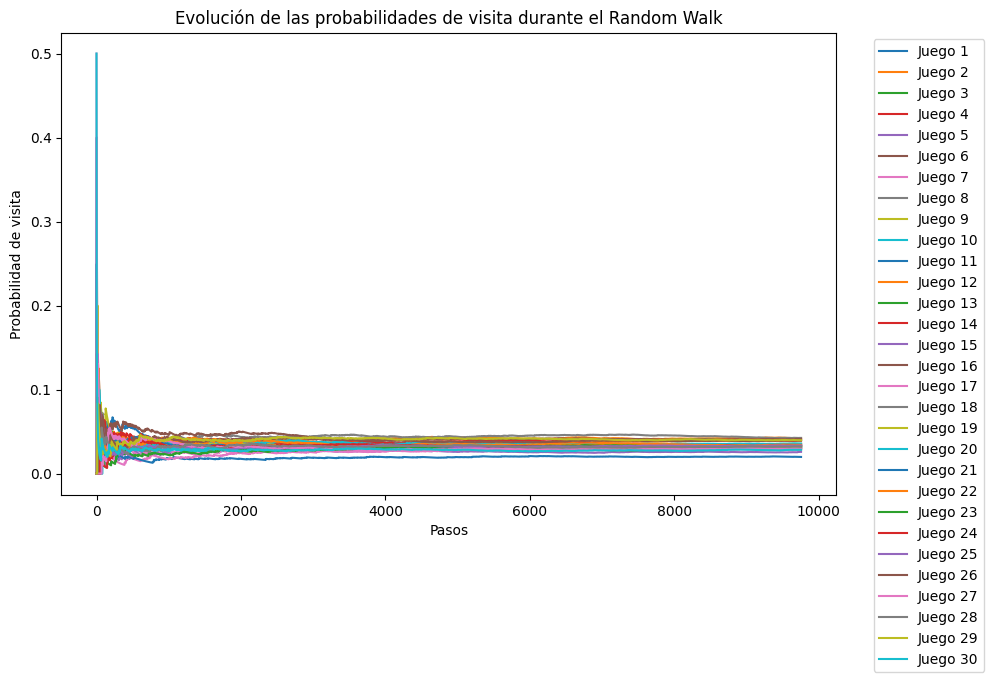

In [20]:
def random_walk(matriz_transicion, epsilon, umbral_convergencia=0.0001, max_pasos=20000):
    estado_actual = np.random.randint(0, n_juegos)

    visitas = np.zeros(n_juegos)
    visitas[estado_actual] += 1

    historial_visitas = []

    distribuciones_previas = np.zeros(n_juegos)

    pasos = 0

    while pasos < max_pasos:
        probabilidad_transicion = matriz_transicion[estado_actual]

        probabilidad_transicion = (1 - epsilon) * probabilidad_transicion + epsilon * np.random.rand(n_juegos)

        probabilidad_transicion /= probabilidad_transicion.sum()

        estado_actual = np.random.choice(n_juegos, p=probabilidad_transicion)

        visitas[estado_actual] += 1

        distribucion_normalizada = visitas / visitas.sum()
        historial_visitas.append(distribucion_normalizada)

        if np.linalg.norm(distribucion_normalizada - distribuciones_previas) < umbral_convergencia:
            break

        distribuciones_previas = distribucion_normalizada

        pasos += 1

    return np.array(historial_visitas), pasos

epsilon = 0.000001

historial_visitas, pasos_totales = random_walk(matriz_transicion, epsilon)

print("\nDistribución final de visitas (después de converger):")
print(historial_visitas[-1])
print(f"\nPasos totales hasta la convergencia: {pasos_totales}")

plt.figure(figsize=(10, 6))
for juego in range(n_juegos):
    plt.plot(historial_visitas[:, juego], label=f"Juego {juego + 1}")

plt.title("Evolución de las probabilidades de visita durante el Random Walk")
plt.xlabel("Pasos")
plt.ylabel("Probabilidad de visita")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

def distribucion_estacionaria(matriz_transicion):
    P_minus_I = matriz_transicion.T - np.eye(n_juegos)
    P_minus_I = np.vstack([P_minus_I, np.ones(n_juegos)])
    pi = np.linalg.lstsq(P_minus_I, np.zeros(n_juegos + 1), rcond=None)[0]
    pi = pi[:n_juegos]
    pi /= pi.sum()

    return pi


Calculamos la distribuición estacionaria, al compararlo con lo obtenido anteriormente se ve una similitud muy alta en los datos, al punto que varian en un punto minimo


In [24]:
from numpy.linalg import eig

def distribucion_estacionaria(matriz_transicion):
    valores_propios, vectores_propios = eig(matriz_transicion.T)


    estacionario = np.real(vectores_propios[:, np.isclose(valores_propios, 1)])
    estacionario = estacionario / estacionario.sum()

    return estacionario.flatten()


distribucion = distribucion_estacionaria(matriz_transicion)

print("\nDistribución estacionaria:")
print(distribucion)



Distribución estacionaria:
[0.03697762 0.0413762  0.03032532 0.03731502 0.02636879 0.03490096
 0.02921333 0.04169347 0.02953412 0.03327171 0.02087893 0.03842844
 0.02666025 0.0327533  0.03005404 0.03780932 0.03038586 0.0305688
 0.03505738 0.03392568 0.03453984 0.03529955 0.03342689 0.03321235
 0.03653901 0.03856635 0.03267774 0.03277752 0.03888611 0.0265761 ]
